# Cancer Detection with decision trees

In [1]:
import pandas as pd
raw_df = pd.read_csv("archive (1)/data.csv")
raw_df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [2]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [3]:
raw_df.drop(columns=["Unnamed: 32", "id"], inplace=True)

In [4]:
raw_df.columns
raw_df["diagnosis"] = raw_df["diagnosis"].map({"M": "yes", "B": "no"})

In [5]:
import matplotlib as mt

In [6]:
%pip install seaborn --quiet


Note: you may need to restart the kernel to use updated packages.


In [7]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [8]:
px.histogram(raw_df, x="radius_mean", title="mean radius vs diagnosis", color="diagnosis")

In [9]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [10]:
from sklearn.model_selection import train_test_split
train_val_df, test_df = train_test_split(raw_df, random_state=45, train_size=0.9)
train_df, val_df = train_test_split(train_val_df, random_state=45, train_size=0.9)


In [11]:
print("training set", train_df.shape)
print("testing set", test_df.shape)
print("validation set", val_df.shape)


training set (460, 31)
testing set (57, 31)
validation set (52, 31)


In [12]:
target_col = "diagnosis"
input_cols = list(train_df.columns)[1:31]
train_df["diagnosis"]
print(input_cols)
print(len(input_cols))
train_df.describe()

['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']
30


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,460.000000,460.000000,460.000000,460.000000,460.000000,460.000000,460.000000,460.000000,460.000000,460.000000,...,460.000000,460.000000,460.000000,460.000000,460.000000,460.000000,460.000000,460.000000,460.000000,460.000000
mean,14.104437,19.218326,91.810457,653.796739,0.095801,0.103763,0.088674,0.048425,0.180759,0.062819,...,16.226443,25.576935,106.984239,877.293261,0.132037,0.254762,0.272930,0.114626,0.289694,0.084303
std,3.562597,4.299342,24.601248,357.641123,0.014081,0.054453,0.081740,0.039553,0.028238,0.007164,...,4.865852,6.103889,33.902002,574.236377,0.023222,0.162691,0.214181,0.066690,0.063926,0.018695
min,7.691000,9.710000,47.920000,170.400000,0.052630,0.019380,0.000000,0.000000,0.106000,0.050250,...,8.678000,12.020000,54.490000,223.600000,0.071170,0.027290,0.000000,0.000000,0.156600,0.055210
25%,11.637500,16.130000,74.710000,414.500000,0.085402,0.062315,0.028445,0.019603,0.161375,0.057607,...,12.977500,20.910000,83.822500,513.700000,0.115175,0.143800,0.112300,0.063717,0.249675,0.071730
50%,13.320000,18.770000,85.935000,546.350000,0.094660,0.090840,0.059100,0.032715,0.179300,0.061475,...,14.940000,25.370000,97.620000,684.550000,0.131100,0.210500,0.224800,0.099840,0.280800,0.079985
75%,16.022500,21.735000,104.800000,794.350000,0.104950,0.130525,0.132325,0.070468,0.195300,0.066022,...,18.602500,29.757500,125.025000,1055.000000,0.145700,0.336275,0.386850,0.161675,0.316425,0.092120
max,28.110000,39.280000,188.500000,2501.000000,0.144700,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,47.160000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [13]:
train_df[input_cols].isna().sum()

radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [14]:
%pip install numpy --quiet

Note: you may need to restart the kernel to use updated packages.


In [15]:
import numpy as np
numeric_cols = train_df[input_cols].select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_df[input_cols].select_dtypes(include="object").columns.to_list()
print("numerical columns: ", numeric_cols)
print("categorical cols: ", categorical_cols)

numerical columns:  ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']
categorical cols:  []


In [16]:
train_inputs = train_df[input_cols].copy()
train_target = train_df[target_col].copy()

test_inputs = test_df[input_cols].copy()
test_target = test_df[target_col].copy()

val_inputs = val_df[input_cols].copy()
val_target = val_df[target_col].copy()

In [17]:
train_target

482     no
45     yes
509    yes
433    yes
106     no
      ... 
197    yes
551     no
541     no
403     no
88      no
Name: diagnosis, Length: 460, dtype: object

In [18]:
from sklearn.preprocessing import MinMaxScaler

In [19]:
scaler = MinMaxScaler().fit(raw_df[numeric_cols])
scaler

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [20]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])


In [21]:
train_inputs[numeric_cols]

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
482,0.307113,0.147109,0.300809,0.170859,0.491740,0.294829,0.135567,0.261730,0.363131,0.346040,...,0.245464,0.167910,0.221774,0.116742,0.449911,0.215977,0.147604,0.458763,0.327617,0.250689
45,0.552274,0.266824,0.552208,0.395546,0.517017,0.457702,0.462512,0.501491,0.427778,0.221778,...,0.529705,0.247868,0.498979,0.339609,0.638777,0.467357,0.586661,0.817182,0.440371,0.241440
509,0.401297,0.481569,0.414691,0.249332,0.592850,0.514140,0.475633,0.423459,0.377273,0.439553,...,0.326574,0.647921,0.335126,0.177989,0.673777,0.455424,0.472125,0.743299,0.285433,0.338843
433,0.560320,0.414609,0.552208,0.409968,0.443893,0.366603,0.373477,0.434592,0.445960,0.239259,...,0.524013,0.503998,0.472583,0.348457,0.447930,0.309505,0.312460,0.586942,0.284250,0.184311
106,0.220503,0.291512,0.216847,0.114104,0.555836,0.252500,0.165651,0.173211,0.374242,0.320977,...,0.185343,0.459488,0.174810,0.082703,0.644720,0.231598,0.229473,0.418557,0.244628,0.235668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,0.525297,0.410213,0.508673,0.373489,0.190304,0.205632,0.258435,0.287177,0.358586,0.072452,...,0.420847,0.337953,0.391902,0.256292,0.112593,0.163974,0.202476,0.315498,0.158486,0.069133
551,0.196365,0.430504,0.191417,0.099639,0.388463,0.191890,0.113027,0.112177,0.489899,0.327717,...,0.145500,0.432836,0.136411,0.061787,0.247837,0.146414,0.124920,0.220378,0.316184,0.165814
541,0.354442,0.516740,0.359478,0.217561,0.322651,0.317833,0.236410,0.193340,0.410101,0.283277,...,0.294913,0.525320,0.314209,0.153288,0.414911,0.381203,0.322684,0.414089,0.319732,0.309983
403,0.282029,0.218465,0.272200,0.154443,0.416719,0.211582,0.077226,0.118787,0.340909,0.253580,...,0.210957,0.293177,0.195627,0.097252,0.303969,0.163489,0.144569,0.288247,0.341415,0.152827


# Training with decison trees

In [22]:
from sklearn.tree import DecisionTreeClassifier

In [23]:
model = DecisionTreeClassifier(random_state= 50)

In [24]:
%%time
model.fit(train_inputs, train_target)

CPU times: total: 0 ns
Wall time: 18.1 ms


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,50
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [26]:
train_preds = model.predict(train_inputs)
train_preds

array(['no', 'yes', 'yes', 'yes', 'no', 'yes', 'no', 'no', 'yes', 'no',
       'yes', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 'no', 'no', 'yes',
       'no', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 'no', 'yes', 'no',
       'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'yes', 'yes',
       'no', 'no', 'yes', 'no', 'yes', 'no', 'no', 'no', 'no', 'no',
       'yes', 'no', 'no', 'no', 'yes', 'no', 'no', 'yes', 'yes', 'no',
       'no', 'yes', 'no', 'no', 'no', 'no', 'yes', 'yes', 'no', 'no',
       'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no',
       'yes', 'yes', 'no', 'no', 'yes', 'no', 'no', 'yes', 'yes', 'yes',
       'yes', 'yes', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'yes',
       'no', 'yes', 'yes', 'no', 'no', 'no', 'yes', 'no', 'yes', 'no',
       'no', 'no', 'yes', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no',
       'yes', 'yes', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'yes',
       'yes', 'no', 'no', 'no', 'no', 'no', 'yes', 'yes', 'no', 'no

In [27]:
print(pd.value_counts(train_target))
print(pd.value_counts(train_preds))

diagnosis
no     294
yes    166
Name: count, dtype: int64
no     294
yes    166
Name: count, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23484\4269488164.py:1: FutureWarning:

pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23484\4269488164.py:2: FutureWarning:

pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.



In [28]:
val_pred = model.predict(val_inputs)
test_preds = model.predict(test_inputs)

In [29]:
print(pd.value_counts(val_target))
print(pd.value_counts(val_pred))

diagnosis
yes    30
no     22
Name: count, dtype: int64
yes    31
no     21
Name: count, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23484\178288568.py:1: FutureWarning:

pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23484\178288568.py:2: FutureWarning:

pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.



In [30]:
accuracy_score(train_target, train_target)

1.0

In [31]:
accuracy_score(test_target, test_preds)

0.9649122807017544

In [32]:
from sklearn.tree import plot_tree, export_text

[Text(0.5, 0.875, 'concave points_worst <= 0.489\ngini = 0.461\nsamples = 460\nvalue = [294, 166]'),
 Text(0.25, 0.625, 'radius_worst <= 0.348\ngini = 0.143\nsamples = 310\nvalue = [286, 24]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'perimeter_worst <= 0.257\ngini = 0.066\nsamples = 293\nvalue = [283, 10]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'fractal_dimension_worst <= 0.065\ngini = 0.291\nsamples = 17\nvalue = [3, 14]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'area_worst <= 0.123\ngini = 0.101\nsamples = 150\nvalue = [8, 142]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'smoothness_mean <= 0.504\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'concavity_worst <= 0.162\ngini = 0.028\nsamples = 140\nvalue = [2, 138]'),
 Text(0.8125, 0.125, '\n  (...)  \

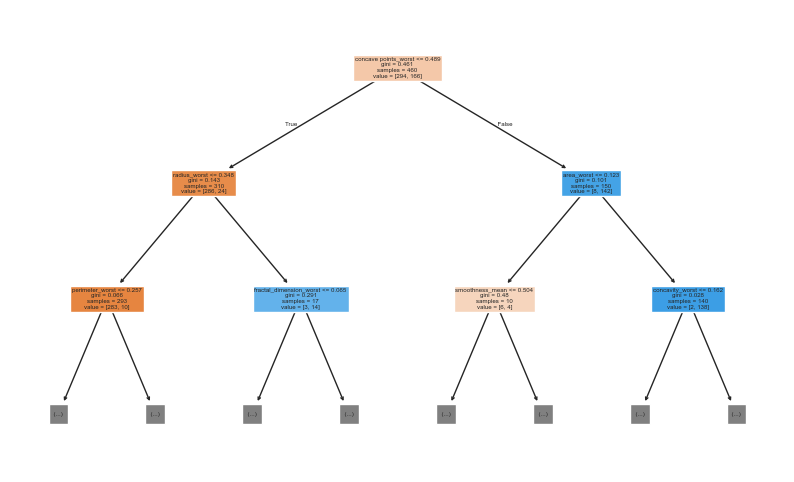

In [33]:
plt.Figure(figsize=(100, 100))
plot_tree(model, feature_names=train_inputs.columns, max_depth=2,filled=True )

In [34]:
model.tree_.max_depth

7

In [38]:
tree_text = export_text(model, feature_names=list(train_inputs.columns))
print(tree_text, end=" ")

|--- concave points_worst <= 0.49
|   |--- radius_worst <= 0.35
|   |   |--- perimeter_worst <= 0.26
|   |   |   |--- texture_worst <= 0.57
|   |   |   |   |--- class: no
|   |   |   |--- texture_worst >  0.57
|   |   |   |   |--- texture_worst <= 0.57
|   |   |   |   |   |--- class: yes
|   |   |   |   |--- texture_worst >  0.57
|   |   |   |   |   |--- class: no
|   |   |--- perimeter_worst >  0.26
|   |   |   |--- texture_worst <= 0.46
|   |   |   |   |--- smoothness_worst <= 0.45
|   |   |   |   |   |--- concave points_se <= 0.34
|   |   |   |   |   |   |--- class: no
|   |   |   |   |   |--- concave points_se >  0.34
|   |   |   |   |   |   |--- concave points_se <= 0.40
|   |   |   |   |   |   |   |--- class: yes
|   |   |   |   |   |   |--- concave points_se >  0.40
|   |   |   |   |   |   |   |--- class: no
|   |   |   |   |--- smoothness_worst >  0.45
|   |   |   |   |   |--- class: yes
|   |   |   |--- texture_worst >  0.46
|   |   |   |   |--- perimeter_mean <= 0.35
|   |   

In [39]:
model.feature_importances_

array([0.00706909, 0.        , 0.01178182, 0.        , 0.03047564,
       0.        , 0.0015031 , 0.        , 0.        , 0.00706909,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.00913091, 0.        , 0.        ,
       0.09437375, 0.03182963, 0.01457575, 0.03017942, 0.01665049,
       0.        , 0.00922397, 0.71992001, 0.        , 0.01621733])

In [40]:
importance_df = pd.DataFrame({"feature": train_inputs.columns, "importance": model.feature_importances_}).sort_values("importance", ascending=False)

In [41]:
importance_df

,feature,importance
27,concave points_worst,0.719920
20,radius_worst,0.094374
21,texture_worst,0.031830
4,smoothness_mean,0.030476
23,area_worst,0.030179
24,smoothness_worst,0.016650
29,fractal_dimension_worst,0.016217
22,perimeter_worst,0.014576
2,perimeter_mean,0.011782
26,concavity_worst,0.009224


<Axes: title={'center': 'importance'}, xlabel='importance', ylabel='feature'>

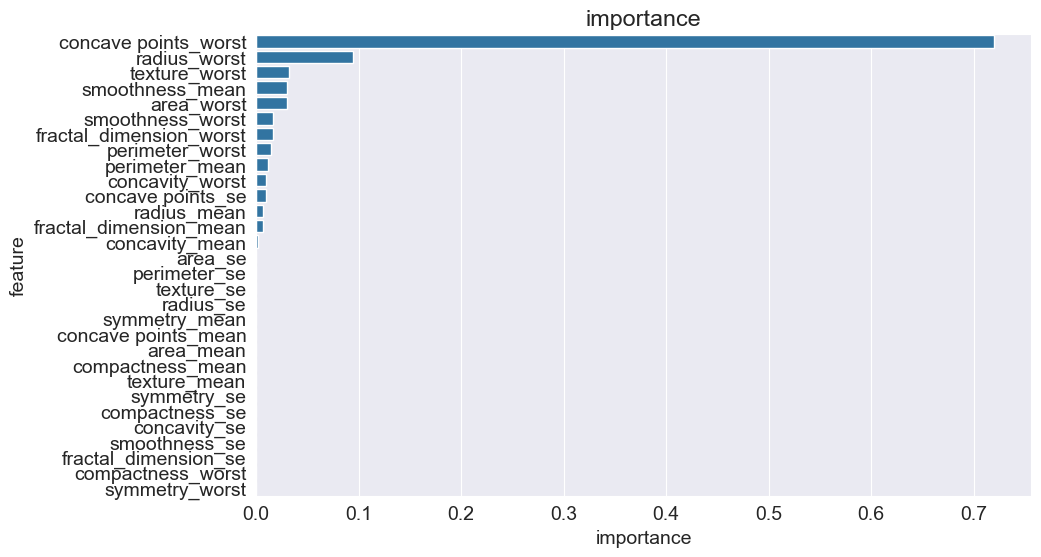

In [44]:
plt.title("importance")
sns.barplot(data=importance_df, x= "importance", y = "feature")